# Regresión Lineal Múltiple
### Predicción del costo del seguro médico

**Dataset:** insurance.csv — 1,338 personas  
**Columnas disponibles:** age, sex, bmi, children, smoker, region, charges  
**Variable objetivo (Y):** charges (costo del seguro en USD)

**Flujo del notebook:**
1. Importar librerías
2. Cargar datos
3. Codificar variables categóricas
4. Análisis de correlación de Pearson
5. Visualización: Edad vs Cargos promedio
6. Normalización Min-Max
7. Dividir en entrenamiento y prueba
8. Entrenar modelo
9. Evaluar métricas
10. Predecir nuevo cliente

In [1]:
# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================
# pandas     → manipular datos en tablas (DataFrame)
# numpy      → operaciones matemáticas con arreglos
# matplotlib → generar gráficas
# sklearn    → herramientas de Machine Learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# ============================================================
# 2. CARGAR DATOS
# ============================================================
df = pd.read_csv("insurance.csv")

print("Primeras 5 filas del dataset:")
print(df.head())

print("\nDimensiones (filas x columnas):", df.shape)

print("\nEstadísticas generales:")
print(df.describe())

Primeras 5 filas del dataset:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dimensiones (filas x columnas): (1338, 7)

Estadísticas generales:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  

In [3]:
# ============================================================
# 3. CODIFICAR VARIABLES CATEGÓRICAS
# ============================================================
# Los modelos de ML solo operan con números.
# Las columnas de texto se convierten así:
#
#   Columna con 2 valores → Binarización con .map()
#     sex:    'male'→1, 'female'→0
#     smoker: 'yes'→1,  'no'→0
#
#   Columna con 3+ valores → One-Hot Encoding con get_dummies()
#     region tiene 4 categorías: northeast, northwest, southeast, southwest
#     get_dummies() crea una columna por categoría con 1 o 0.
#     Evita que el modelo asuma que hay un orden entre las regiones
#     (si usáramos 0,1,2,3 parecería que una región es 'mayor' que otra).

df_enc = df.copy()

df_enc['sex']    = df_enc['sex'].map({'male': 1, 'female': 0})
df_enc['smoker'] = df_enc['smoker'].map({'yes': 1, 'no': 0})
df_enc = pd.get_dummies(df_enc, columns=['region'], dtype=int)

print("Columnas resultantes:")
print(df_enc.columns.tolist())
print("\nPrimeras filas codificadas:")
print(df_enc.head())

Columnas resultantes:
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']

Primeras filas codificadas:
   age  sex     bmi  children  smoker      charges  region_northeast  \
0   19    0  27.900         0       1  16884.92400                 0   
1   18    1  33.770         1       0   1725.55230                 0   
2   28    1  33.000         3       0   4449.46200                 0   
3   33    1  22.705         0       0  21984.47061                 0   
4   32    1  28.880         0       0   3866.85520                 0   

   region_northwest  region_southeast  region_southwest  
0                 0                 0                 1  
1                 0                 1                 0  
2                 0                 1                 0  
3                 1                 0                 0  
4                 1                 0                 0  


In [4]:
# ============================================================
# 4. CORRELACIÓN DE PEARSON — con detección automática
# ============================================================
# El coeficiente r indica qué tan relacionada está cada variable
# con 'charges'. Va de -1 a 1 (valor absoluto):
#
#   0.8-1.0 → muy alta   0.6-0.8 → alta
#   0.4-0.6 → moderada   0.2-0.4 → baja
#   0.0-0.2 → muy baja   0.0     → nula
#
# El signo indica dirección: + sube juntas, - van en sentido opuesto.

correlacion = df_enc.corr()['charges'].drop('charges').sort_values(
    key=abs, ascending=False
)

print("Correlación de cada variable con charges:")
print("=" * 50)
for col, val in correlacion.items():
    barra = '█' * int(abs(val) * 35)
    signo = '+' if val >= 0 else '-'
    print(f"{col:<22} {signo}{abs(val):.3f}  {barra}")

# ── Detección automática de la variable más influyente ──
# En lugar de asumir cuál es la más importante, el código la encuentra solo.
variable_top   = correlacion.abs().idxmax()
correlacion_top = correlacion.abs().max()

print(f"\n→ Variable con mayor correlación: '{variable_top}' (r = {correlacion_top:.3f})")
print(f"  Esta variable explica la mayor parte del costo del seguro.")

Correlación de cada variable con charges:
smoker                 +0.787  ███████████████████████████
age                    +0.299  ██████████
bmi                    +0.198  ██████
region_southeast       +0.074  ██
children               +0.068  ██
sex                    +0.057  ██
region_southwest       -0.043  █
region_northwest       -0.040  █
region_northeast       +0.006  

→ Variable con mayor correlación: 'smoker' (r = 0.787)
  Esta variable explica la mayor parte del costo del seguro.


Cargos promedio por edad (primeras filas):
   age       charges
0   18   7086.217556
1   19   9747.909335
2   20  10159.697736
3   21   4730.464330
4   22  10012.932802
5   23  12419.820040
6   24  10648.015962
7   25   9838.365311
8   26   6133.825309
9   27  12184.701721


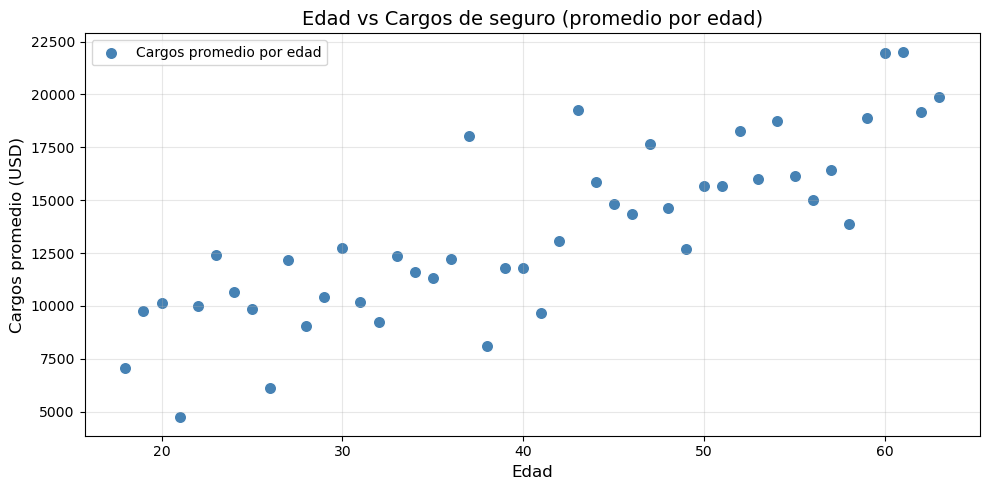


→ La gráfica muestra que a mayor edad, generalmente mayor costo.
  Pero hay dispersión: otros factores (como fumar) también influyen.


In [5]:
# ============================================================
# 5. VISUALIZACIÓN: Edad vs Cargos promedio
# ============================================================
# Construimos un dataset con el costo promedio del seguro
# para cada edad (de 18 a 63 años), y lo graficamos.
# Esto nos permite ver visualmente la relación entre edad y precio.

# Calcular cargos promedio por edad
dataset_edad_cargos_data = []

for edad in range(18, 64):
    cargos          = df.query('age == ' + str(edad)).charges
    cargos_promedio = np.mean(cargos)
    dataset_edad_cargos_data.append({'age': edad, 'charges': cargos_promedio})

dataset_edad_cargos = pd.DataFrame(dataset_edad_cargos_data)

print("Cargos promedio por edad (primeras filas):")
print(dataset_edad_cargos.head(10))

# Gráfica de dispersión
plt.figure(figsize=(10, 5))

plt.scatter(
    dataset_edad_cargos['age'],
    dataset_edad_cargos['charges'],
    color='steelblue',
    edgecolors='white',
    s=80,
    label='Cargos promedio por edad'
)

plt.title('Edad vs Cargos de seguro (promedio por edad)', fontsize=14)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Cargos promedio (USD)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\n→ La gráfica muestra que a mayor edad, generalmente mayor costo.")
print("  Pero hay dispersión: otros factores (como fumar) también influyen.")

In [6]:
# ============================================================
# 6. NORMALIZACIÓN MIN-MAX
# ============================================================
# ¿Por qué normalizar?
#   Las variables tienen escalas muy diferentes:
#     age: 18–64       bmi: 15–53       charges: 1121–63770
#
#   Si no normalizamos, 'charges' domina todo porque sus números
#   son miles de veces más grandes. El modelo se confunde.
#
# ¿Qué hace Min-Max?
#   Lleva todos los valores al rango [0, 1] usando:
#   X_norm = (X - X_min) / (X_max - X_min)
#
#   Ejemplo con edad:
#     edad = 39  →  (39 - 18) / (64 - 18)  =  21/46  ≈  0.456
#
# ¿Qué NO se normaliza?
#   smoker y sex ya son 0 o 1, están en la misma escala. Dejarlos así.
#
# ¡IMPORTANTE! Guardamos los min/max ANTES de normalizar.
#   Los necesitamos al final para desnormalizar la predicción
#   y que el resultado sea en dólares reales, no en [0, 1].

features = ['age', 'bmi', 'smoker', 'sex']

X = df_enc[features].values
y = df_enc['charges'].values

# Guardar rangos originales (antes de modificar)
edad_min, edad_max = X[:, 0].min(), X[:, 0].max()
bmi_min,  bmi_max  = X[:, 1].min(), X[:, 1].max()
y_min,    y_max    = y.min(),        y.max()

print("Rangos ANTES de normalizar:")
print(f"  age:     {edad_min:.0f} – {edad_max:.0f}")
print(f"  bmi:     {bmi_min:.2f} – {bmi_max:.2f}")
print(f"  charges: {y_min:.2f} – {y_max:.2f}")

# Aplicar normalización
X[:, 0] = (X[:, 0] - edad_min) / (edad_max - edad_min)  # age
X[:, 1] = (X[:, 1] - bmi_min)  / (bmi_max  - bmi_min)   # bmi
y       = (y       - y_min)    / (y_max     - y_min)      # charges
# X[:,2] smoker: ya es 0/1, no se toca
# X[:,3] sex:    ya es 0/1, no se toca

print("\nRangos DESPUÉS de normalizar (deben ser 0.0 – 1.0):")
print(f"  age:     {X[:, 0].min():.2f} – {X[:, 0].max():.2f}")
print(f"  bmi:     {X[:, 1].min():.2f} – {X[:, 1].max():.2f}")
print(f"  charges: {y.min():.2f} – {y.max():.2f}")

Rangos ANTES de normalizar:
  age:     18 – 64
  bmi:     15.96 – 53.13
  charges: 1121.87 – 63770.43

Rangos DESPUÉS de normalizar (deben ser 0.0 – 1.0):
  age:     0.00 – 1.00
  bmi:     0.00 – 1.00
  charges: 0.00 – 1.00


In [7]:
# ============================================================
# 7. DIVIDIR EN ENTRENAMIENTO Y PRUEBA (80% / 20%)
# ============================================================
# El modelo aprende de X_train / y_train (1070 filas).
# Luego predice sobre X_test y comparamos contra y_test (268 filas)
# para medir qué tan bien generaliza con datos que nunca vio.
#
# random_state=42 fija el "azar" → misma división siempre,
# resultados reproducibles.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} muestras (80%)")
print(f"Prueba:         {X_test.shape[0]} muestras (20%)")

Entrenamiento: 1070 muestras (80%)
Prueba:         268 muestras (20%)


In [8]:
# ============================================================
# 8. CREAR Y ENTRENAR EL MODELO
# ============================================================
# LinearRegression de sklearn usa Mínimos Cuadrados para encontrar
# los coeficientes w que minimizan el error total.
#
# La ecuación resultante es:
#   charges = w1*age + w2*bmi + w3*smoker + w4*sex + b
#
# El coeficiente de cada variable indica cuánto afecta al precio:
#   coef. positivo → sube el precio
#   coef. negativo → baja el precio
#   coef. grande   → más influencia

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print(f"Intercepto (b): {round(modelo.intercept_, 4)}")
print("\nCoeficientes aprendidos (w):")
for nombre, coef in zip(features, modelo.coef_):
    impacto = '↑ sube precio' if coef > 0 else '↓ baja precio'
    print(f"  {nombre:<10}: {round(coef, 4):>8}   {impacto}")

Intercepto (b): -0.0472

Coeficientes aprendidos (w):
  age       :   0.1905   ↑ sube precio
  bmi       :   0.1937   ↑ sube precio
  smoker    :   0.3779   ↑ sube precio
  sex       :   0.0001   ↑ sube precio


MÉTRICAS DEL MODELO
MAE:  0.068
MSE:  0.0088
R²:   0.7777

→ El modelo explica el 77.8% de la variación en el costo.


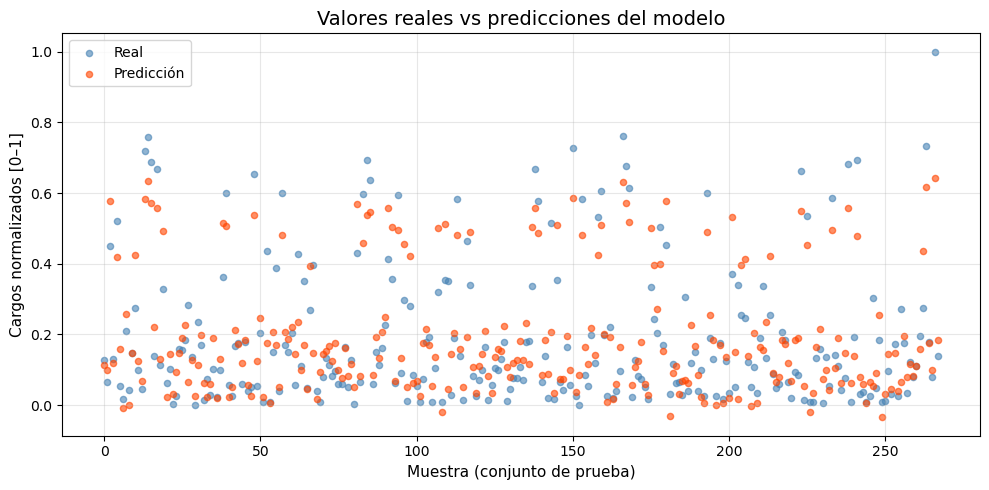

In [9]:
# ============================================================
# 9. EVALUAR CON MÉTRICAS + GRÁFICA DE PREDICCIONES
# ============================================================
# Predecimos sobre el conjunto de prueba y calculamos:
#
#   MAE (Mean Absolute Error)
#     → Promedio de los errores absolutos.
#     → Fácil de interpretar: si MAE=0.08 en escala [0,1],
#       el modelo se equivoca en promedio ±8% del rango del precio.
#
#   MSE (Mean Squared Error)
#     → Promedio de los errores al cuadrado.
#     → Penaliza más los errores grandes. Sensible a outliers.
#
#   R² (Coeficiente de Determinación)
#     → % de la variación en charges que explica el modelo.
#     → R²=0.75 significa que el 75% de los cambios en el precio
#       son explicados por las variables que usamos.
#     → Cercano a 1 = buen modelo | Cercano a 0 = modelo pobre.

predicciones = modelo.predict(X_test)

mae = mean_absolute_error(y_test, predicciones)
mse = mean_squared_error(y_test, predicciones)
r2  = r2_score(y_test, predicciones)

print("============================")
print("MÉTRICAS DEL MODELO")
print("============================")
print(f"MAE:  {round(mae, 4)}")
print(f"MSE:  {round(mse, 4)}")
print(f"R²:   {round(r2, 4)}")
print(f"\n→ El modelo explica el {round(r2 * 100, 1)}% de la variación en el costo.")

# Gráfica: valores reales vs predicciones
plt.figure(figsize=(10, 5))
indices = range(len(y_test))

plt.scatter(indices, y_test,       color='steelblue',  alpha=0.6, s=20, label='Real')
plt.scatter(indices, predicciones, color='orangered',  alpha=0.6, s=20, label='Predicción')

plt.title('Valores reales vs predicciones del modelo', fontsize=14)
plt.xlabel('Muestra (conjunto de prueba)', fontsize=11)
plt.ylabel('Cargos normalizados [0–1]', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# 10. PREDECIR UN NUEVO CLIENTE
# ============================================================
# El modelo predice en escala normalizada [0,1].
# Para obtener el precio real en dólares hay que DESNORMALIZAR:
#   precio_real = prediccion_norm * (y_max - y_min) + y_min
#
# Usamos los mismos y_min / y_max que guardamos antes de normalizar.
# Si usáramos otros valores, el resultado sería incorrecto.

edad_nueva    = 30
bmi_nuevo     = 28.0
fumador_nuevo = 1     # 1 = sí fuma  | 0 = no fuma
genero_nuevo  = 1     # 1 = masculino | 0 = femenino

# Normalizar con los rangos del dataset original
edad_norm = (edad_nueva - edad_min) / (edad_max - edad_min)
bmi_norm  = (bmi_nuevo  - bmi_min)  / (bmi_max  - bmi_min)

nuevo_cliente  = [[edad_norm, bmi_norm, fumador_nuevo, genero_nuevo]]
pred_norm      = modelo.predict(nuevo_cliente)
pred_real      = (pred_norm[0] * (y_max - y_min)) + y_min

print("============================")
print("NUEVO CLIENTE")
print("============================")
print(f"Edad:    {edad_nueva} años")
print(f"BMI:     {bmi_nuevo}")
print(f"Fumador: {'Sí' if fumador_nuevo == 1 else 'No'}")
print(f"Género:  {'Masculino' if genero_nuevo == 1 else 'Femenino'}")
print(f"\nCosto estimado del seguro: ${round(pred_real, 2)} USD")

NUEVO CLIENTE
Edad:    30 años
BMI:     28.0
Fumador: Sí
Género:  Masculino

Costo estimado del seguro: $28894.41 USD


---

## Nota final

Profesor, me disculpo por no haber asistido a la sesión del sábado y por no haberle avisado con anticipación. Tuve un percance familiar que requirió mi atención de manera inesperada y no me fue posible comunicarme en ese momento.

Entiendo que la asistencia y la comunicación forman parte del compromiso con el diplomado, por lo que presento este notebook como evidencia del trabajo correspondiente a la actividad y la tarea de la sesión. Revisé los materiales compartidos, investigué los conceptos vistos en clase y desarrollé el ejercicio de Regresión Lineal Múltiple de manera completa, incluyendo la codificación de variables, el análisis de correlación de Pearson, la normalización, el entrenamiento del modelo, las métricas de evaluación y la predicción para un nuevo cliente.

Quedo pendiente de cualquier indicación adicional o corrección que considere necesaria.

Gracias por su comprensión.

